In [ ]:
# ── Parámetros a ajustar manualmente ──────────────────────────────────────────
P0_BINARY   = 0.05
P1_BINARY   = 270
P0_RRLYRAE  = 0.15
P1_RRLYRAE  = 1.0
P0_CEFEID   = 0.2
P1_CEFEID   = 150
P_NUM       = 10000
N_SAMPLE    = 5
RANDOM_SEED = 7

ACTIVE_TYPES = ["binary", "rrlyrae", "cefeid"]  # subconjunto a procesar

# ── Grilla de configuraciones a explorar ─────────────────────────────────────
# Grillas cuadradas L x L (L = K). Se prueban todas las combinaciones.
# En el nuevo método L = divisiones en fase, K = divisiones en magnitud.
PARTS_VALUES = list(range(2, 11))   # prueba 2x2, 3x3, ..., 15x15
# ──────────────────────────────────────────────────────────────────────────────

In [2]:
# Cargar datos
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import testing as tst
import random
import least_entropy_threshold_claude as le
from datetime import datetime

COLLECTIONS = {
    "binary": {
        "dat_dir":  "ogle_collection/binaries_phot",
        "ref_file": "ogle_collection/binaries.txt",
        "p_col":    "P",
        "p0": P0_BINARY,
        "p1": P1_BINARY,
    },
    "rrlyrae": {
        "dat_dir":  "ogle_collection/rrlyrae_phot",
        "ref_file": "ogle_collection/rrlyrae.txt",
        "p_col":    "P_1",
        "p0": P0_RRLYRAE,
        "p1": P1_RRLYRAE,
    },
    "cefeid": {
        "dat_dir":  "ogle_collection/classical_cefeids_phot",
        "ref_file": "ogle_collection/classical_cefeids.txt",
        "p_col":    "P_1",
        "p0": P0_CEFEID,
        "p1": P1_CEFEID,
    },
}


def load_reference(ref_file, p_col):
    df_ref = pd.read_csv(ref_file, skiprows=6, sep=r"\s+")
    ref = {}
    for _, row in df_ref.iterrows():
        ref[str(row["ID"])] = {
            "mag_I":  row["I"],
            "p_true": row[p_col],
        }
    return ref


# ── Validar ACTIVE_TYPES ──────────────────────────────────────────────────────
invalid = set(ACTIVE_TYPES) - set(COLLECTIONS)
if invalid:
    raise ValueError(f"Tipos no reconocidos en ACTIVE_TYPES: {invalid}")

# ── Validar PARTS_VALUES ──────────────────────────────────────────────────────
if not PARTS_VALUES:
    raise ValueError("PARTS_VALUES está vacío.")
if any(v < 2 for v in PARTS_VALUES):
    raise ValueError(f"Todos los valores de PARTS_VALUES deben ser >= 2. Encontrado: {PARTS_VALUES}")

print(f"Grilla: {len(PARTS_VALUES)} configuraciones {PARTS_VALUES[0]}x{PARTS_VALUES[0]} ... {PARTS_VALUES[-1]}x{PARTS_VALUES[-1]}")

# ── Pre-cargar datos y referencias una sola vez ───────────────────────────────
loaded_data = {}

for tipo, cfg in COLLECTIONS.items():
    if tipo not in ACTIVE_TYPES:
        continue

    print(f"Cargando datos: {tipo.upper()}")

    try:
        ref = load_reference(cfg["ref_file"], cfg["p_col"])
    except Exception as e:
        print(f"  [ERROR] No se pudo cargar la referencia {cfg['ref_file']}: {e}")
        continue

    archivos = [f for f in os.listdir(cfg["dat_dir"]) if f.endswith(".dat")]

    if N_SAMPLE is not None and N_SAMPLE < len(archivos):
        rng = random.Random(RANDOM_SEED)
        archivos = rng.sample(archivos, N_SAMPLE)

    loaded_data[tipo] = []
    for archivo in archivos:
        nombre = archivo.split(".")[0]
        ruta   = os.path.join(cfg["dat_dir"], archivo)

        if nombre not in ref:
            continue

        p_true = ref[nombre]["p_true"]

        if not (cfg["p0"] <= p_true <= cfg["p1"]):
            print(f"  [SKIP] {nombre} — p_true={p_true:.4f} fuera del rango [{cfg['p0']}, {cfg['p1']}]")
            continue

        try:
            data = pd.read_csv(ruta, sep=" ", lineterminator="\n", names=("t", "u", "inc_u"))
            loaded_data[tipo].append({
                "nombre": nombre,
                "data":   data,
                "p_true": p_true,
                "mag_I":  ref[nombre]["mag_I"],
            })
        except Exception as e:
            print(f"  [ERROR] {nombre} — no se pudo leer: {e}")

    print(f"  {len(loaded_data[tipo])} estrellas listas.")

print("\nDatos pre-cargados. Iniciando barrido de grilla...")

Grilla: 14 configuraciones 2x2 ... 15x15
Cargando datos: BINARY
  5 estrellas listas.
Cargando datos: RRLYRAE
  5 estrellas listas.
Cargando datos: CEFEID
  5 estrellas listas.

Datos pre-cargados. Iniciando barrido de grilla...


In [3]:
# ── Barrido de grilla ─────────────────────────────────────────────────────────
all_results = []
print(f"Total configuraciones: {len(PARTS_VALUES)}  |  Tipos activos: {ACTIVE_TYPES}")

for parts in tqdm(PARTS_VALUES, desc="Grilla"):
    for tipo, cfg in COLLECTIONS.items():
        if tipo not in ACTIVE_TYPES or tipo not in loaded_data:
            continue

        for entry in loaded_data[tipo]:
            nombre = entry["nombre"]
            data   = entry["data"]
            p_true = entry["p_true"]
            mag_I  = entry["mag_I"]

            try:
                p_found, min_entropy, phases1, phases2, periods, entropies = le.find_best_period(
                    data,
                    p0=cfg["p0"], p1=cfg["p1"],
                    p_num=P_NUM,
                    L=parts,
                    K=parts,
                    plot_entropies=False,
                    name=nombre,
                )
            except Exception as e:
                print(f"  [ERROR] {nombre} ({parts}x{parts}) — {e}")
                continue

            error    = tst.period_error(p_found, p_true)
            multiple = tst.which_multiple(p_found, p_true)

            all_results.append({
                "id":       nombre,
                "tipo":     tipo,
                "mag_I":    mag_I,
                "p_true":   p_true,
                "p_found":  p_found,
                "parts":    parts,
                "error":    error,
                "multiple": multiple,
                "success":  error < 0.05,
            })

df_results = pd.DataFrame(all_results)
print(f"\nListo. {len(df_results)} resultados totales.")
print(df_results.groupby(["tipo", "parts"])["success"].mean().rename("recovery_rate"))

Total configuraciones: 14  |  Tipos activos: ['binary', 'rrlyrae', 'cefeid']


Grilla: 100%|██████████| 14/14 [43:54<00:00, 188.15s/it]



Listo. 210 resultados totales.
tipo     parts
binary   2        0.0
         3        0.2
         4        0.4
         5        0.2
         6        0.4
         7        0.4
         8        0.4
         9        0.4
         10       0.0
         11       0.2
         12       0.4
         13       0.2
         14       0.2
         15       0.2
cefeid   2        0.4
         3        0.8
         4        1.0
         5        0.8
         6        0.8
         7        0.6
         8        0.8
         9        0.8
         10       1.0
         11       0.8
         12       0.8
         13       0.8
         14       0.8
         15       0.8
rrlyrae  2        0.4
         3        0.8
         4        0.8
         5        0.8
         6        0.8
         7        0.8
         8        0.8
         9        0.8
         10       0.8
         11       0.8
         12       0.8
         13       0.8
         14       0.8
         15       0.8
Name: recovery_rate, dtype: f

In [4]:
# ── Exportar resultados ───────────────────────────────────────────────────────
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("resultados_masivos", exist_ok=True)

df_results.to_csv(f"resultados_masivos/grilla_threshold_resultados_{timestamp}.csv", index=False)

params = {
    "timestamp":     timestamp,
    "metodo":        "least_entropy_threshold_claude",
    "P0_BINARY":     P0_BINARY,
    "P1_BINARY":     P1_BINARY,
    "P0_RRLYRAE":    P0_RRLYRAE,
    "P1_RRLYRAE":    P1_RRLYRAE,
    "P0_CEFEID":     P0_CEFEID,
    "P1_CEFEID":     P1_CEFEID,
    "P_NUM":         P_NUM,
    "N_SAMPLE":      N_SAMPLE,
    "RANDOM_SEED":   RANDOM_SEED,
    "ACTIVE_TYPES":  str(ACTIVE_TYPES),
    "PARTS_VALUES":  str(PARTS_VALUES),
}
pd.DataFrame([params]).to_csv(f"resultados_masivos/grilla_threshold_params_{timestamp}.csv", index=False)

print(f"Resultados en: resultados_masivos/grilla_threshold_resultados_{timestamp}.csv")
print(f"Parámetros en: resultados_masivos/grilla_threshold_params_{timestamp}.csv")

Resultados en: resultados_masivos/grilla_threshold_resultados_20260423_225711.csv
Parámetros en: resultados_masivos/grilla_threshold_params_20260423_225711.csv


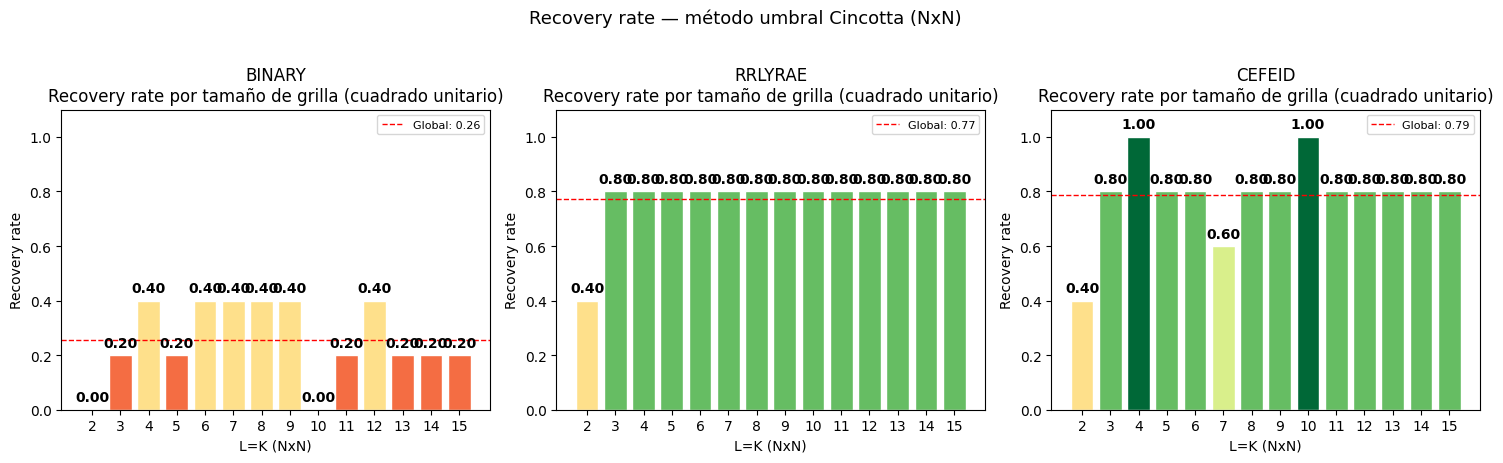

Gráfico guardado en: resultados_masivos/grilla_threshold_heatmap_20260423_225711.png


In [5]:
# ── Gráfico de recovery rate por parts y tipo ─────────────────────────────────
n_tipos = len(ACTIVE_TYPES)
fig, axes = plt.subplots(1, n_tipos, figsize=(5 * n_tipos, 4.5))
if n_tipos == 1:
    axes = [axes]

cmap = plt.cm.RdYlGn

for ax, tipo in zip(axes, ACTIVE_TYPES):
    df_tipo  = df_results[df_results["tipo"] == tipo]
    recovery = df_tipo.groupby("parts")["success"].mean()

    colors = [cmap(v) for v in recovery.values]
    bars   = ax.bar(recovery.index.astype(str), recovery.values, color=colors, edgecolor="white")

    for bar, val in zip(bars, recovery.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color="black")

    ax.set_ylim(0, 1.1)
    ax.set_xlabel("L=K (NxN)")
    ax.set_ylabel("Recovery rate")
    ax.set_title(f"{tipo.upper()}\nRecovery rate por tamaño de grilla (cuadrado unitario)")
    ax.axhline(df_tipo["success"].mean(), color="red", linestyle="--",
               linewidth=1, label=f"Global: {df_tipo['success'].mean():.2f}")
    ax.legend(fontsize=8)

plt.suptitle("Recovery rate — método umbral Cincotta (NxN)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"resultados_masivos/grilla_threshold_heatmap_{timestamp}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico guardado en: resultados_masivos/grilla_threshold_heatmap_{timestamp}.png")

In [6]:
# ── Resumen: mejores configuraciones por tipo ─────────────────────────────────
print("Mejores configuraciones por tipo:\n")
for tipo in ACTIVE_TYPES:
    df_tipo = df_results[df_results["tipo"] == tipo]
    ranking = (
        df_tipo.groupby("parts")["success"]
        .mean()
        .rename("recovery_rate")
        .reset_index()
        .sort_values("recovery_rate", ascending=False)
    )
    ranking["grilla"] = ranking["parts"].astype(str) + "x" + ranking["parts"].astype(str)
    print(f"  {tipo.upper()}:")
    print(ranking[["grilla", "recovery_rate"]].to_string(index=False))
    print()

Mejores configuraciones por tipo:

  BINARY:
grilla  recovery_rate
   6x6            0.4
   4x4            0.4
   7x7            0.4
 12x12            0.4
   9x9            0.4
   8x8            0.4
 14x14            0.2
   5x5            0.2
   3x3            0.2
 11x11            0.2
 15x15            0.2
 13x13            0.2
   2x2            0.0
 10x10            0.0

  RRLYRAE:
grilla  recovery_rate
   3x3            0.8
   4x4            0.8
   6x6            0.8
   5x5            0.8
   7x7            0.8
   8x8            0.8
 12x12            0.8
   9x9            0.8
 10x10            0.8
 11x11            0.8
 14x14            0.8
 13x13            0.8
 15x15            0.8
   2x2            0.4

  CEFEID:
grilla  recovery_rate
   4x4            1.0
 10x10            1.0
   6x6            0.8
   5x5            0.8
   8x8            0.8
   3x3            0.8
 12x12            0.8
 13x13            0.8
   9x9            0.8
 11x11            0.8
 14x14            0.8
 15x15  